# Exploratory Analysis of Bitcoin Daily Log Returns

This notebook focuses on Bitcoin daily log returns. The main forecasting task in the project is to predict the **next-day Bitcoin daily log return**.

The daily log return is calculated from daily close prices:

$$
r_t = \log\left(\frac{P_t}{P_{t-1}}\right)
$$

The one-step-ahead target is:

$$
\text{target}_t = r_{t+1}
$$

So for day \(t\), we use information available up to that day and the target is the close-to-close log return on the next day. Values are kept on the normal return scale, for example \(0.025\) means about **2.5% daily log return**.

## 1. Exploratory Data Analysis

In [1]:
from pathlib import Path
import json
import pickle
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:,.6f}".format

Matplotlib is building the font cache; this may take a moment.


In [2]:
DAILY_DATA_PATH = Path("data/BTC/BTC_USD_coinbase_spot_daily_features.csv")
METADATA_PATH = Path("data/BTC/BTC_USD_coinbase_spot_daily_features.metadata.json")
SCALER_PATH = Path("data/BTC/BTC_USD_coinbase_spot_daily_features.scaler.pkl")
RAW_5MIN_PATH = Path("data/BTC/BTC_USD_coinbase_spot_5min.csv")

### Load Daily Features

The daily feature file is used mainly for daily OHLCV data and the existing train/test split. Some numeric columns in this file are scaled, so we invert the scaler before using prices and returns.

In [3]:
daily_scaled = pd.read_csv(DAILY_DATA_PATH, parse_dates=["timestamp_utc"])

with METADATA_PATH.open("r", encoding="utf-8") as file:
    metadata = json.load(file)

with SCALER_PATH.open("rb") as file:
    scaler = pickle.load(file)

scaled_columns = metadata["scaled_columns"]
daily_full = daily_scaled.copy()
daily_full[scaled_columns] = scaler.inverse_transform(daily_scaled[scaled_columns])

daily_full = daily_full.set_index("timestamp_utc").sort_index()
daily_full.head()

,open,high,low,close,volume,product_id,source,observations,expected_observations,coverage_ratio,...,volume_log_lag_1,log_return_lag_2,volume_log_lag_2,log_return_lag_3,volume_log_lag_3,log_return_lag_7,volume_log_lag_7,target_log_return_next,target_direction_next,split
timestamp_utc,,,,,,,,,,,,,,,,,,,,,
2016-05-14 00:00:00+00:00,457.970000,459.830000,456.000000,458.900000,"3,295.199707",BTC-USD,coinbase_exchange_spot,288,288,1.000000,...,8.595118,0.004633,8.719325,0.003505,8.656504,-0.000866,8.150433,0.005585,1.000000,train
2016-05-15 00:00:00+00:00,458.900000,463.620000,458.490000,461.470000,"3,269.982525",BTC-USD,coinbase_exchange_spot,288,288,1.000000,...,8.100525,0.003281,8.595118,0.004633,8.719325,0.001903,8.094555,-0.012670,0.000000,train
2016-05-16 00:00:00+00:00,461.480000,461.590000,451.480000,455.660000,"6,019.172367",BTC-USD,coinbase_exchange_spot,288,288,1.000000,...,8.092846,0.002007,8.100525,0.003281,8.595118,0.002956,8.679982,-0.003231,0.000000,train
2016-05-17 00:00:00+00:00,455.640000,457.490000,452.200000,454.190000,"6,033.908426",BTC-USD,coinbase_exchange_spot,288,288,1.000000,...,8.702871,0.005585,8.092846,0.002007,8.100525,-0.024823,8.826919,0.003012,1.000000,train
2016-05-18 00:00:00+00:00,454.190000,457.880000,453.600000,455.560000,"5,512.423782",BTC-USD,coinbase_exchange_spot,288,288,1.000000,...,8.705316,-0.012670,8.702871,0.005585,8.092846,0.003505,8.656504,-0.038441,0.000000,train


### Build Daily Log Return Target from Prices

The daily feature file already contains daily close-to-close log returns and the next-day target. Here we rebuild returns from the same filtered daily close series as a consistency check and keep intraday realized volatility only as an auxiliary diagnostic for volatility clustering.

In [4]:
raw_5min = pd.read_csv(RAW_5MIN_PATH, parse_dates=["timestamp_utc"])
raw_5min = raw_5min.sort_values("timestamp_utc").set_index("timestamp_utc")

raw_5min["log_close_5m"] = np.log(raw_5min["close"])
raw_5min["intraday_log_return"] = raw_5min["log_close_5m"].diff()
raw_5min["intraday_squared_return"] = raw_5min["intraday_log_return"] ** 2

raw_daily = raw_5min.resample("1D", closed="left", label="left").agg(
    raw_close=("close", "last"),
    intraday_observations=("intraday_log_return", "count"),
    realized_variance=("intraday_squared_return", "sum"),
)
raw_daily["realized_volatility"] = raw_daily["realized_variance"].pow(0.5)
raw_daily["realized_volatility_pct"] = raw_daily["realized_volatility"] * 100

raw_daily[["raw_close", "realized_volatility", "intraday_observations"]].head()

,raw_close,realized_volatility,intraday_observations
timestamp_utc,,,
2016-04-13 00:00:00+00:00,425.580000,0.006405,82
2016-04-14 00:00:00+00:00,426.320000,0.009101,278
2016-04-15 00:00:00+00:00,430.930000,0.008232,278
2016-04-16 00:00:00+00:00,433.390000,0.008115,287
2016-04-17 00:00:00+00:00,431.000000,0.010180,286


In [5]:
daily_full = daily_full.join(
    raw_daily[["raw_close", "intraday_observations", "realized_variance", "realized_volatility", "realized_volatility_pct"]],
    how="left",
)

daily_full["log_return_rebuilt"] = np.log(daily_full["close"] / daily_full["close"].shift(1))
daily_full["target_next_daily_log_return"] = daily_full["log_return"].shift(-1)
daily_full["log_return_pct"] = daily_full["log_return"] * 100
daily_full["target_next_daily_log_return_pct"] = daily_full["target_next_daily_log_return"] * 100
daily_full["abs_log_return"] = daily_full["log_return"].abs()
daily_full["abs_log_return_pct"] = daily_full["abs_log_return"] * 100
daily_full["squared_log_return"] = daily_full["log_return"] ** 2
daily_full["direction"] = np.where(daily_full["log_return"] > 0, "positive", "negative")

return_check = (daily_full["log_return"] - daily_full["log_return_rebuilt"]).abs().dropna()
target_check = (daily_full["target_log_return_next"] - daily_full["target_next_daily_log_return"]).abs().dropna()
print(f"Maximum absolute rebuilt-return difference: {return_check.max():.12f}")
print(f"Maximum absolute target-shift difference: {target_check.max():.12f}")

daily_full[[
    "close",
    "raw_close",
    "log_return",
    "log_return_pct",
    "target_next_daily_log_return",
    "target_next_daily_log_return_pct",
    "split",
]].head()

Maximum absolute rebuilt-return difference: 0.000000000000
Maximum absolute target-shift difference: 0.000000000000


,close,raw_close,log_return,log_return_pct,target_next_daily_log_return,target_next_daily_log_return_pct,split
timestamp_utc,,,,,,,
2016-05-14 00:00:00+00:00,458.900000,458.900000,0.002007,0.200681,0.005585,0.558473,train
2016-05-15 00:00:00+00:00,461.470000,461.470000,0.005585,0.558473,-0.012670,-1.267013,train
2016-05-16 00:00:00+00:00,455.660000,455.660000,-0.012670,-1.267013,-0.003231,-0.323130,train
2016-05-17 00:00:00+00:00,454.190000,454.190000,-0.003231,-0.323130,0.003012,0.301182,train
2016-05-18 00:00:00+00:00,455.560000,455.560000,0.003012,0.301182,-0.038441,-3.844132,train


### Final Forecasting Setup

For the later models: use data up to day `t` -> predict `r_{t+1}`.

`r_t` is the daily close-to-close log return. Intraday realized volatility is kept in this notebook only as supporting evidence about clustering and changing risk regimes, not as the main target.

### Dataset Overview

The EDA below uses only the training period. The test period is kept separate for later model evaluation.

In [6]:
train_daily = daily_full.loc[daily_full["split"] == "train"].copy()
test_daily = daily_full.loc[daily_full["split"] == "test"].copy()

# Use only the training split for exploratory analysis and statistical diagnostics.
daily = train_daily.copy()

print(f"Full rows: {len(daily_full):,}")
print(f"Training rows used below: {len(daily):,}")
print(f"Test rows held out: {len(test_daily):,}")
print(f"Columns: {daily_full.shape[1]}")
print(f"Training start date: {daily.index.min().date()}")
print(f"Training end date: {daily.index.max().date()}")
print(f"Test start date: {test_daily.index.min().date()}")
print(f"Test end date: {test_daily.index.max().date()}")
print(f"Training missing values: {daily.isna().sum().sum()}")
print(f"Duplicated dates in full data: {daily_full.index.duplicated().sum()}")

Full rows: 3,595
Training rows used below: 2,876
Test rows held out: 719
Columns: 55
Training start date: 2016-05-14
Training end date: 2024-04-21
Test start date: 2024-04-22
Test end date: 2026-04-11
Training missing values: 1
Duplicated dates in full data: 0


In [7]:
daily[[
    "open",
    "high",
    "low",
    "close",
    "volume",
    "log_return",
    "log_return_pct",
    "target_next_daily_log_return",
    "split",
]].head()

,open,high,low,close,volume,log_return,log_return_pct,target_next_daily_log_return,split
timestamp_utc,,,,,,,,,
2016-05-14 00:00:00+00:00,457.970000,459.830000,456.000000,458.900000,"3,295.199707",0.002007,0.200681,0.005585,train
2016-05-15 00:00:00+00:00,458.900000,463.620000,458.490000,461.470000,"3,269.982525",0.005585,0.558473,-0.012670,train
2016-05-16 00:00:00+00:00,461.480000,461.590000,451.480000,455.660000,"6,019.172367",-0.012670,-1.267013,-0.003231,train
2016-05-17 00:00:00+00:00,455.640000,457.490000,452.200000,454.190000,"6,033.908426",-0.003231,-0.323130,0.003012,train
2016-05-18 00:00:00+00:00,454.190000,457.880000,453.600000,455.560000,"5,512.423782",0.003012,0.301182,-0.038441,train


### Missing Values and Daily Coverage

In [8]:
missing_values = daily.isna().sum().to_frame("missing_values")
missing_values["missing_share"] = missing_values["missing_values"] / len(daily)

missing_values[missing_values["missing_values"] > 0]

,missing_values,missing_share
log_return_rebuilt,1,0.000348


In [9]:
daily[[
    "observations",
    "expected_observations",
    "coverage_ratio",
    "intraday_observations",
]].describe().T

,count,mean,std,min,25%,50%,75%,max
observations,"2,876.000000",287.883171,0.914947,274.000000,288.000000,288.000000,288.000000,288.000000
expected_observations,"2,876.000000",288.000000,0.000000,288.000000,288.000000,288.000000,288.000000,288.000000
coverage_ratio,"2,876.000000",0.999594,0.003177,0.951389,1.000000,1.000000,1.000000,1.000000
intraday_observations,"2,876.000000",287.883171,0.914947,274.000000,288.000000,288.000000,288.000000,288.000000


In [10]:
date_gaps = daily.index.to_series().diff()
date_gaps.value_counts().head(10)

timestamp_utc
1 days    2854
2 days      19
3 days       1
4 days       1
Name: count, dtype: int64

In [11]:
long_gaps = date_gaps[date_gaps > pd.Timedelta(days=1)]

gap_details = pd.DataFrame({
    "previous_date": [daily.index[daily.index.get_loc(date) - 1] for date in long_gaps.index],
    "current_date": long_gaps.index,
    "gap_length": long_gaps.values,
})

gap_details.head(30)

,previous_date,current_date,gap_length
0,2016-07-10 00:00:00+00:00,2016-07-12 00:00:00+00:00,2 days
1,2016-09-18 00:00:00+00:00,2016-09-20 00:00:00+00:00,2 days
2,2016-10-14 00:00:00+00:00,2016-10-17 00:00:00+00:00,3 days
3,2017-01-15 00:00:00+00:00,2017-01-17 00:00:00+00:00,2 days
4,2017-02-27 00:00:00+00:00,2017-03-03 00:00:00+00:00,4 days
5,2017-04-14 00:00:00+00:00,2017-04-16 00:00:00+00:00,2 days
6,2017-09-24 00:00:00+00:00,2017-09-26 00:00:00+00:00,2 days
7,2017-11-30 00:00:00+00:00,2017-12-02 00:00:00+00:00,2 days
8,2017-12-11 00:00:00+00:00,2017-12-13 00:00:00+00:00,2 days
9,2018-01-31 00:00:00+00:00,2018-02-02 00:00:00+00:00,2 days


### Summary Statistics

In [12]:
main_columns = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "log_return",
    "log_return_pct",
    "abs_log_return_pct",
    "squared_log_return",
    "target_next_daily_log_return",
    "target_next_daily_log_return_pct",
]

daily[main_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
open,"2,876.000000","19,230.301516","17,750.227910",437.910000,"6,182.212500","10,761.145000","29,944.395000","73,135.040000"
high,"2,876.000000","19,724.111318","18,205.686873",445.850000,"6,327.085000","11,042.000000","30,514.187500","73,835.570000"
low,"2,876.000000","18,689.424871","17,240.955405",435.000000,"5,915.907500","10,357.825000","29,366.237500","71,337.300000"
close,"2,876.000000","19,252.577827","17,767.239204",438.380000,"6,187.565000","10,761.145000","29,997.347500","73,135.040000"
volume,"2,876.000000","15,382.968834","12,024.176569","1,315.729558","7,307.838495","12,412.803049","19,570.020540","130,316.646844"
log_return,"2,876.000000",0.001723,0.038554,-0.491226,-0.013254,0.001555,0.018310,0.240606
log_return_pct,"2,876.000000",0.172274,3.855389,-49.122610,-1.325352,0.155485,1.830966,24.060603
abs_log_return_pct,"2,876.000000",2.546560,2.899395,0.000719,0.620399,1.563659,3.469091,49.122610
squared_log_return,"2,876.000000",0.001489,0.005597,0.000000,0.000038,0.000245,0.001203,0.241303
target_next_daily_log_return,"2,876.000000",0.001732,0.038557,-0.491226,-0.013254,0.001555,0.018364,0.240606


In [13]:
largest_positive_return_date = daily["log_return"].idxmax()
largest_negative_return_date = daily["log_return"].idxmin()
largest_absolute_return_date = daily["abs_log_return"].idxmax()

print("Largest positive daily log return:")
print(largest_positive_return_date.date(), f"{daily.loc[largest_positive_return_date, 'log_return_pct']:.2f}%")

print("\nLargest negative daily log return:")
print(largest_negative_return_date.date(), f"{daily.loc[largest_negative_return_date, 'log_return_pct']:.2f}%")

print("\nLargest absolute daily log return:")
print(largest_absolute_return_date.date(), f"{daily.loc[largest_absolute_return_date, 'abs_log_return_pct']:.2f}%")

Largest positive daily log return:
2017-07-20 24.06%

Largest negative daily log return:
2020-03-12 -49.12%

Largest absolute daily log return:
2020-03-12 49.12%


### Price, Volume, and Daily Log Returns

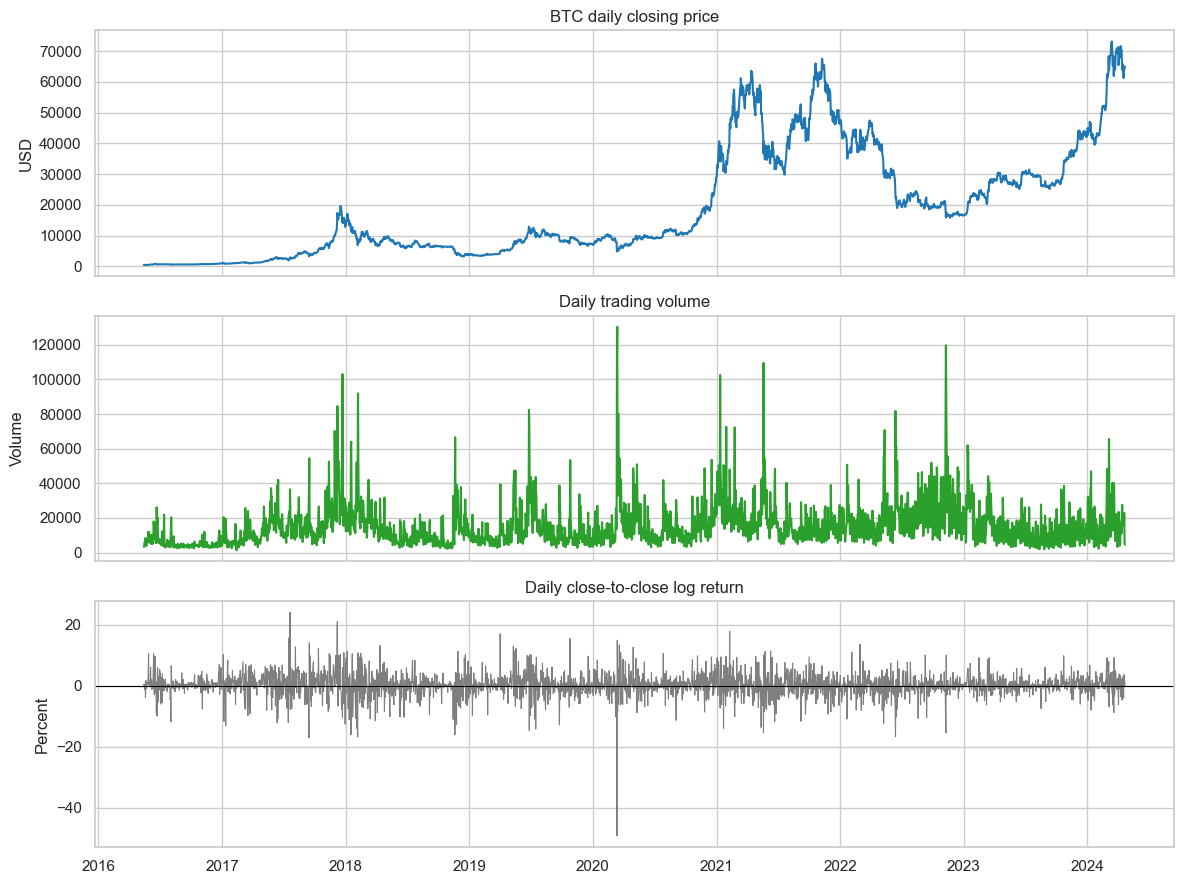

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(daily.index, daily["close"], color="tab:blue")
axes[0].set_title("BTC daily closing price")
axes[0].set_ylabel("USD")

axes[1].plot(daily.index, daily["volume"], color="tab:green")
axes[1].set_title("Daily trading volume")
axes[1].set_ylabel("Volume")

axes[2].plot(daily.index, daily["log_return_pct"], color="tab:gray", linewidth=0.8)
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("Daily close-to-close log return")
axes[2].set_ylabel("Percent")

plt.tight_layout()
plt.show()

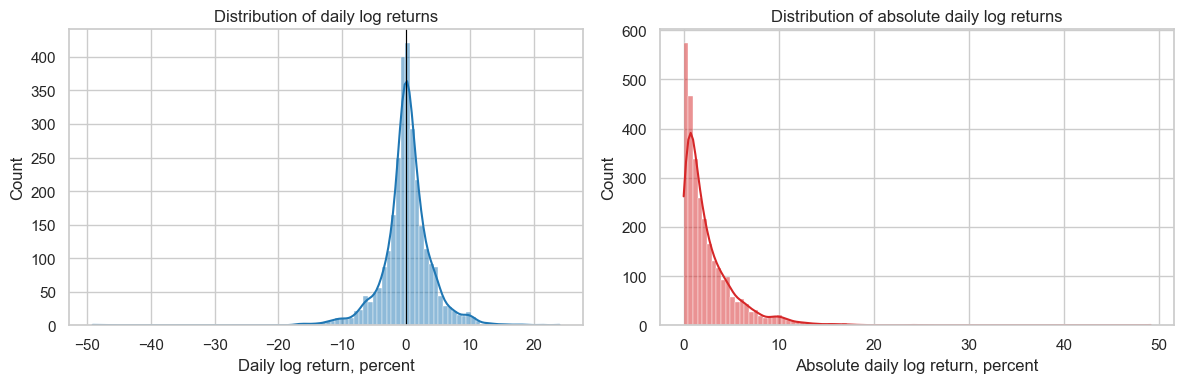

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(daily["log_return_pct"].dropna(), bins=100, kde=True, ax=axes[0], color="tab:blue")
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Distribution of daily log returns")
axes[0].set_xlabel("Daily log return, percent")

sns.histplot(daily["abs_log_return_pct"].dropna(), bins=100, kde=True, ax=axes[1], color="tab:red")
axes[1].set_title("Distribution of absolute daily log returns")
axes[1].set_xlabel("Absolute daily log return, percent")

plt.tight_layout()
plt.show()

## 2. Trend, Seasonality, and Volatility

This section checks how daily log returns behave over time. We look at the return level, rolling return volatility, calendar patterns, and volatility clustering in absolute and squared returns.

### Trend

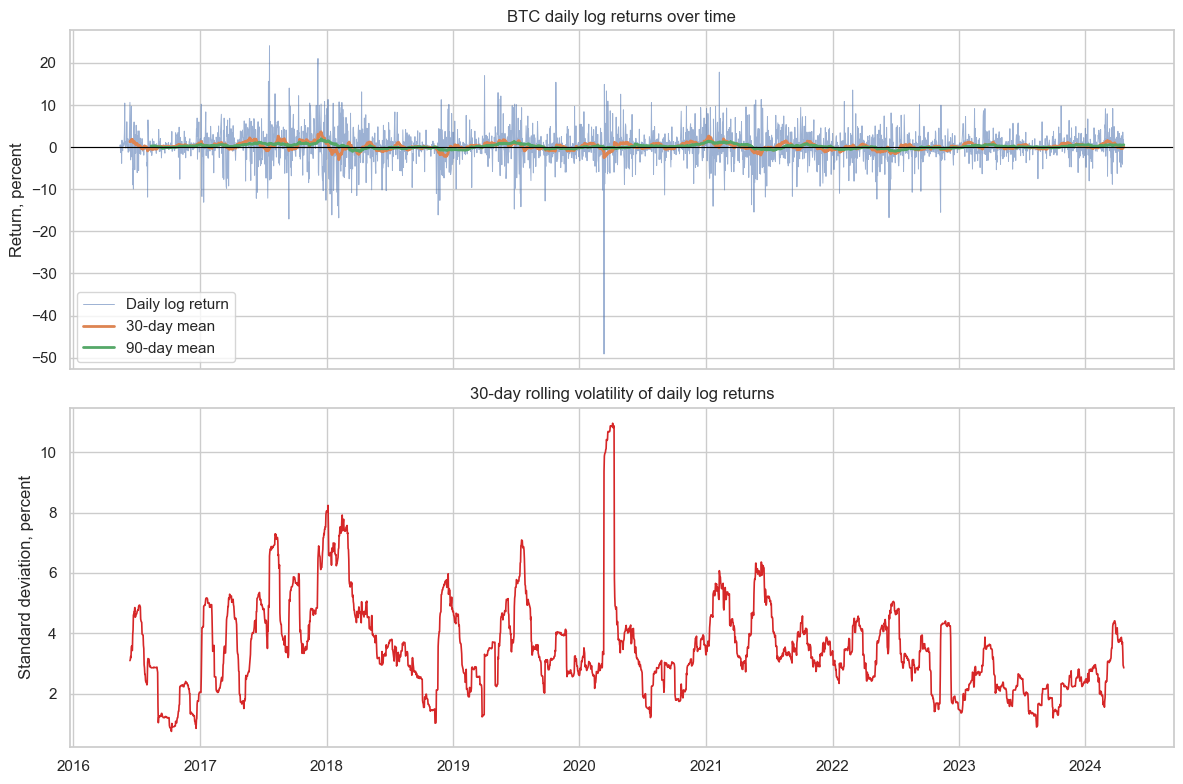

In [16]:
daily["return_30d_mean"] = daily["log_return"].rolling(30).mean()
daily["return_90d_mean"] = daily["log_return"].rolling(90).mean()
daily["return_30d_volatility"] = daily["log_return"].rolling(30).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(daily.index, daily["log_return_pct"], label="Daily log return", linewidth=0.7, alpha=0.55)
axes[0].plot(daily.index, daily["return_30d_mean"] * 100, label="30-day mean", linewidth=2)
axes[0].plot(daily.index, daily["return_90d_mean"] * 100, label="90-day mean", linewidth=2)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("BTC daily log returns over time")
axes[0].set_ylabel("Return, percent")
axes[0].legend()

axes[1].plot(daily.index, daily["return_30d_volatility"] * 100, color="tab:red", linewidth=1.2)
axes[1].set_title("30-day rolling volatility of daily log returns")
axes[1].set_ylabel("Standard deviation, percent")

plt.tight_layout()
plt.show()

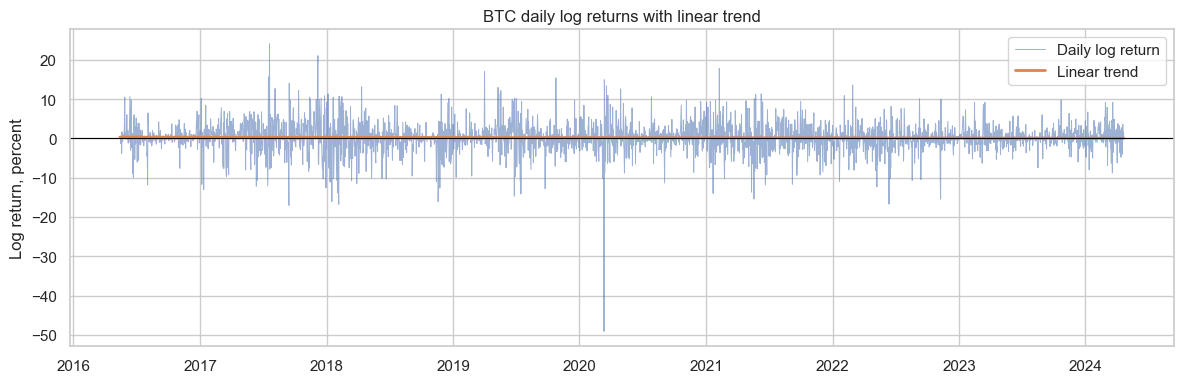

In [17]:
return_trend_data = daily["log_return"].dropna()
x = np.arange(len(return_trend_data))
trend_coef = np.polyfit(x, return_trend_data, 1)
trend_line = np.polyval(trend_coef, x)

plt.figure(figsize=(12, 4))
plt.plot(return_trend_data.index, return_trend_data * 100, label="Daily log return", linewidth=0.7, alpha=0.55)
plt.plot(return_trend_data.index, trend_line * 100, label="Linear trend", linewidth=2)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("BTC daily log returns with linear trend")
plt.ylabel("Log return, percent")
plt.legend()
plt.tight_layout()
plt.show()

### Seasonality

In [18]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

daily["weekday"] = daily.index.day_name()
daily["month"] = daily.index.month_name()

weekday_summary = daily.groupby("weekday")["log_return"].agg(
    days="count",
    mean_return="mean",
    median_return="median",
    return_volatility="std",
    mean_absolute_return=lambda x: x.abs().mean(),
    positive_share=lambda x: (x > 0).mean(),
).reindex(weekday_order)

weekday_summary.assign(
    mean_return_pct=weekday_summary["mean_return"] * 100,
    median_return_pct=weekday_summary["median_return"] * 100,
    return_volatility_pct=weekday_summary["return_volatility"] * 100,
    mean_absolute_return_pct=weekday_summary["mean_absolute_return"] * 100,
)

,days,mean_return,median_return,return_volatility,mean_absolute_return,positive_share,mean_return_pct,median_return_pct,return_volatility_pct,mean_absolute_return_pct
weekday,,,,,,,,,,
Monday,409,0.003809,0.000114,0.042232,0.029693,0.501222,0.380854,0.011381,4.223229,2.969335
Tuesday,411,0.000835,0.002288,0.036784,0.025995,0.527981,0.083540,0.228772,3.678408,2.599468
Wednesday,412,0.003265,0.002962,0.040618,0.028205,0.543689,0.326500,0.296179,4.061784,2.820487
Thursday,406,-0.000870,-0.000791,0.048718,0.029490,0.485222,-0.087030,-0.079092,4.871767,2.948983
Friday,412,0.001735,0.002924,0.038443,0.026118,0.553398,0.173459,0.292412,3.844324,2.611812
Saturday,412,0.003024,0.002006,0.029931,0.018913,0.584951,0.302428,0.200585,2.993096,1.891298
Sunday,414,0.000244,0.000104,0.029876,0.019963,0.502415,0.024409,0.010387,2.987569,1.996274


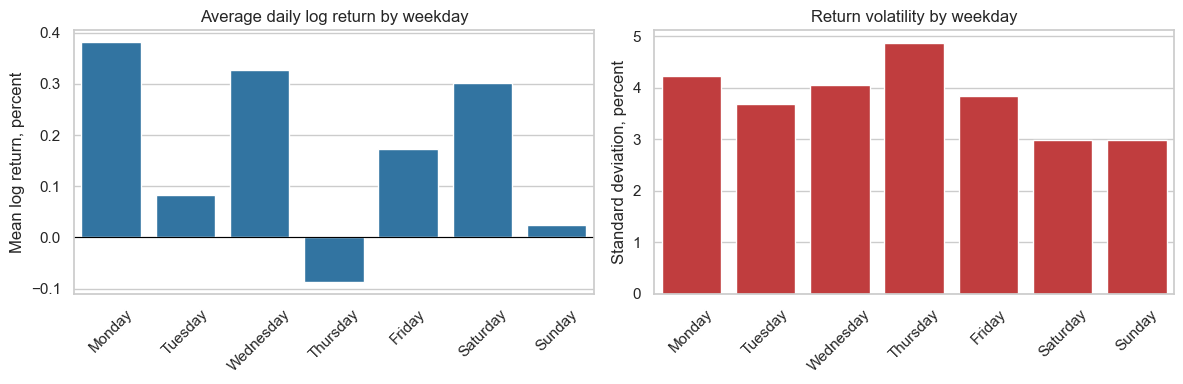

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

weekday_plot = weekday_summary.reset_index()
weekday_plot["mean_return_pct"] = weekday_plot["mean_return"] * 100
weekday_plot["return_volatility_pct"] = weekday_plot["return_volatility"] * 100

sns.barplot(
    data=weekday_plot,
    x="weekday",
    y="mean_return_pct",
    ax=axes[0],
    color="tab:blue",
)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Average daily log return by weekday")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean log return, percent")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=weekday_plot,
    x="weekday",
    y="return_volatility_pct",
    ax=axes[1],
    color="tab:red",
)
axes[1].set_title("Return volatility by weekday")
axes[1].set_xlabel("")
axes[1].set_ylabel("Standard deviation, percent")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [20]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

monthly_summary = daily.groupby("month")["log_return"].agg(
    days="count",
    mean_return="mean",
    median_return="median",
    return_volatility="std",
    mean_absolute_return=lambda x: x.abs().mean(),
    positive_share=lambda x: (x > 0).mean(),
).reindex(month_order)

monthly_summary.assign(
    mean_return_pct=monthly_summary["mean_return"] * 100,
    median_return_pct=monthly_summary["median_return"] * 100,
    return_volatility_pct=monthly_summary["return_volatility"] * 100,
    mean_absolute_return_pct=monthly_summary["mean_absolute_return"] * 100,
)

,days,mean_return,median_return,return_volatility,mean_absolute_return,positive_share,mean_return_pct,median_return_pct,return_volatility_pct,mean_absolute_return_pct
month,,,,,,,,,,
January,246,0.000643,0.002555,0.040606,0.027246,0.544715,0.064343,0.255474,4.060613,2.724630
February,224,0.004620,0.002237,0.041071,0.027483,0.549107,0.461981,0.223702,4.107129,2.748323
March,245,-0.000089,0.002089,0.052050,0.031735,0.555102,-0.008858,0.208859,5.204975,3.173501
April,229,0.003501,0.002760,0.032573,0.022775,0.550218,0.350080,0.276022,3.257320,2.277501
May,234,0.001463,0.003783,0.040942,0.029467,0.551282,0.146300,0.378315,4.094204,2.946742
June,238,-0.000315,0.003170,0.043660,0.031225,0.537815,-0.031477,0.316951,4.366016,3.122481
July,247,0.002852,0.000108,0.037943,0.024576,0.510121,0.285156,0.010840,3.794266,2.457579
August,247,0.000623,-0.000970,0.029898,0.021311,0.465587,0.062264,-0.096955,2.989757,2.131127
September,238,-0.001581,-0.000439,0.033179,0.020624,0.487395,-0.158148,-0.043852,3.317920,2.062382


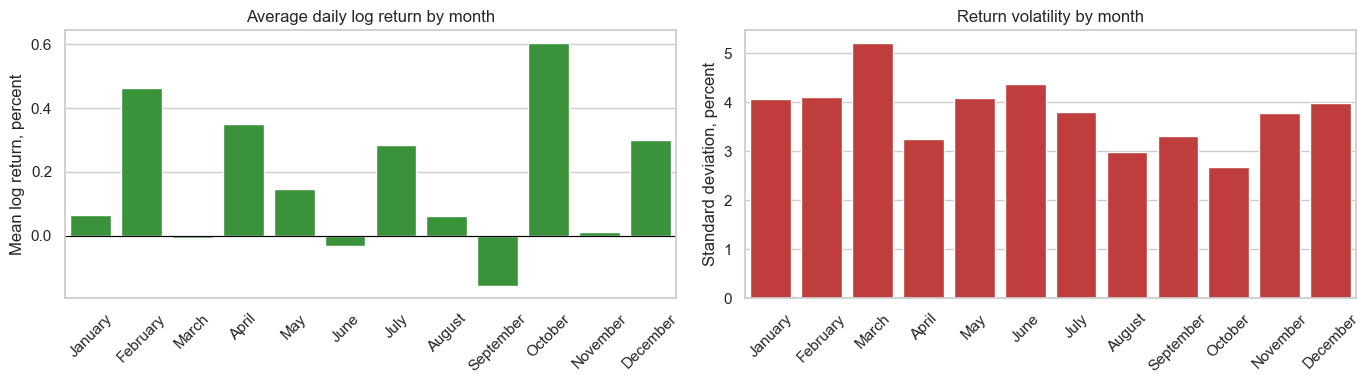

In [21]:
monthly_plot = monthly_summary.reset_index()
monthly_plot["mean_return_pct"] = monthly_plot["mean_return"] * 100
monthly_plot["return_volatility_pct"] = monthly_plot["return_volatility"] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(
    data=monthly_plot,
    x="month",
    y="mean_return_pct",
    color="tab:green",
    ax=axes[0],
)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Average daily log return by month")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean log return, percent")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=monthly_plot,
    x="month",
    y="return_volatility_pct",
    color="tab:red",
    ax=axes[1],
)
axes[1].set_title("Return volatility by month")
axes[1].set_xlabel("")
axes[1].set_ylabel("Standard deviation, percent")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Volatility Clustering

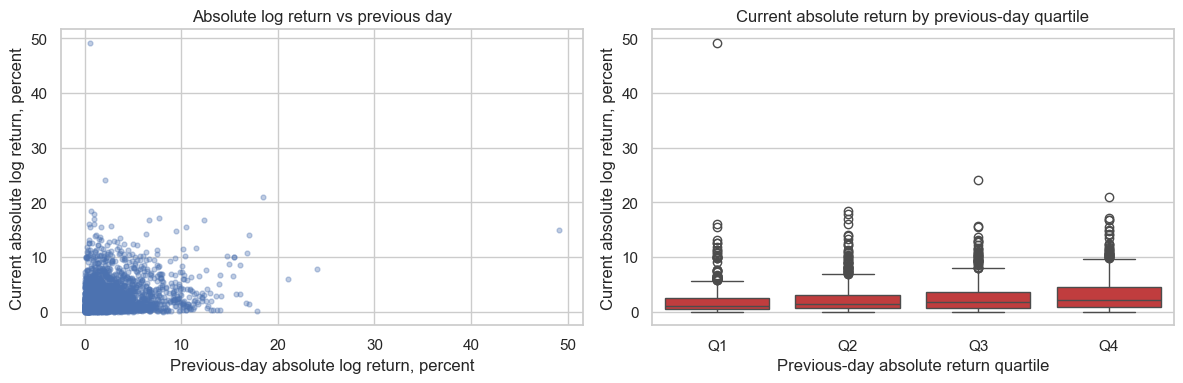

In [22]:
daily["abs_log_return_lag_1"] = daily["abs_log_return"].shift(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(
    daily["abs_log_return_lag_1"] * 100,
    daily["abs_log_return"] * 100,
    alpha=0.35,
    s=12,
)
axes[0].set_title("Absolute log return vs previous day")
axes[0].set_xlabel("Previous-day absolute log return, percent")
axes[0].set_ylabel("Current absolute log return, percent")

quartile_data = daily.dropna(subset=["abs_log_return_lag_1", "abs_log_return_pct"]).copy()
quartile_data["previous_abs_return_quartile"] = pd.qcut(
    quartile_data["abs_log_return_lag_1"],
    4,
    labels=["Q1", "Q2", "Q3", "Q4"],
)

sns.boxplot(
    data=quartile_data,
    x="previous_abs_return_quartile",
    y="abs_log_return_pct",
    ax=axes[1],
    color="tab:red",
)
axes[1].set_title("Current absolute return by previous-day quartile")
axes[1].set_xlabel("Previous-day absolute return quartile")
axes[1].set_ylabel("Current absolute log return, percent")

plt.tight_layout()
plt.show()

In [23]:
largest_return_moves = daily.sort_values("abs_log_return", ascending=False)[
    ["close", "log_return", "log_return_pct", "abs_log_return_pct", "volume", "realized_volatility_pct"]
].head(10)

largest_return_moves

,close,log_return,log_return_pct,abs_log_return_pct,volume,realized_volatility_pct
timestamp_utc,,,,,,
2020-03-12 00:00:00+00:00,"4,857.100000",-0.491226,-49.122610,49.122610,"113,902.203329",23.306892
2017-07-20 00:00:00+00:00,"2,873.480000",0.240606,24.060603,24.060603,"36,509.305874",11.227162
2017-12-07 00:00:00+00:00,"17,390.010000",0.210431,21.043058,21.043058,"84,528.102371",23.910078
2017-12-06 00:00:00+00:00,"14,090.000000",0.184309,18.430934,18.430934,"51,358.745929",7.724334
2021-02-08 00:00:00+00:00,"46,448.100000",0.178076,17.807628,17.807628,"47,934.010388",8.551269
2017-09-14 00:00:00+00:00,"3,250.400000",-0.170676,-17.067595,17.067595,"36,363.925012",10.483207
2019-04-02 00:00:00+00:00,"4,901.930000",0.169658,16.965812,16.965812,"38,406.932116",11.526609
2018-02-05 00:00:00+00:00,"6,905.190000",-0.167940,-16.793976,16.793976,"59,578.698221",14.752161
2022-06-13 00:00:00+00:00,"22,460.970000",-0.167446,-16.744645,16.744645,"81,724.844694",8.839375


## 3. Stationarity and Autocorrelation

This section checks whether daily log returns are stable enough to model and whether past returns, absolute returns, or squared returns are related to future values.

### Stationarity Tests

In [24]:
def stationarity_tests(series, series_name):
    clean_series = series.dropna()
    adf_result = adfuller(clean_series, autolag="AIC")
    kpss_result = kpss(clean_series, regression="c", nlags="auto")

    return pd.Series({
        "series": series_name,
        "observations": len(clean_series),
        "adf_statistic": adf_result[0],
        "adf_pvalue": adf_result[1],
        "kpss_statistic": kpss_result[0],
        "kpss_pvalue": kpss_result[1],
    })

In [25]:
stationarity_summary = pd.DataFrame([
    stationarity_tests(daily["close"], "close price"),
    stationarity_tests(daily["log_close"], "log close price"),
    stationarity_tests(daily["log_return"], "daily log return"),
    stationarity_tests(daily["abs_log_return"], "absolute daily log return"),
    stationarity_tests(daily["squared_log_return"], "squared daily log return"),
    stationarity_tests(daily["realized_volatility"], "realized volatility, auxiliary"),
])

stationarity_summary

,series,observations,adf_statistic,adf_pvalue,kpss_statistic,kpss_pvalue
0,close price,2876,-1.066348,0.728304,5.607333,0.010000
1,log close price,2876,-2.044257,0.267511,6.981373,0.010000
2,daily log return,2876,-37.219589,0.000000,0.212566,0.100000
3,absolute daily log return,2876,-6.863374,0.000000,1.007242,0.010000
4,squared daily log return,2876,-16.952523,0.000000,0.825102,0.010000
5,"realized volatility, auxiliary",2876,-6.152559,0.000000,0.912134,0.010000


The stationarity tests show that the BTC close price and log close price are non-stationary. Their ADF p-values are high, so we fail to reject the presence of a unit root, while the KPSS p-values are low, so we reject stationarity.

Daily log returns appear much more suitable for time-series modeling. The ADF test rejects a unit root, and the KPSS result is typically less problematic than for price levels.

Absolute and squared log returns describe the size of market moves rather than their direction. They are useful diagnostics for volatility clustering: even when raw returns have weak autocorrelation, the magnitude of returns can remain persistent.

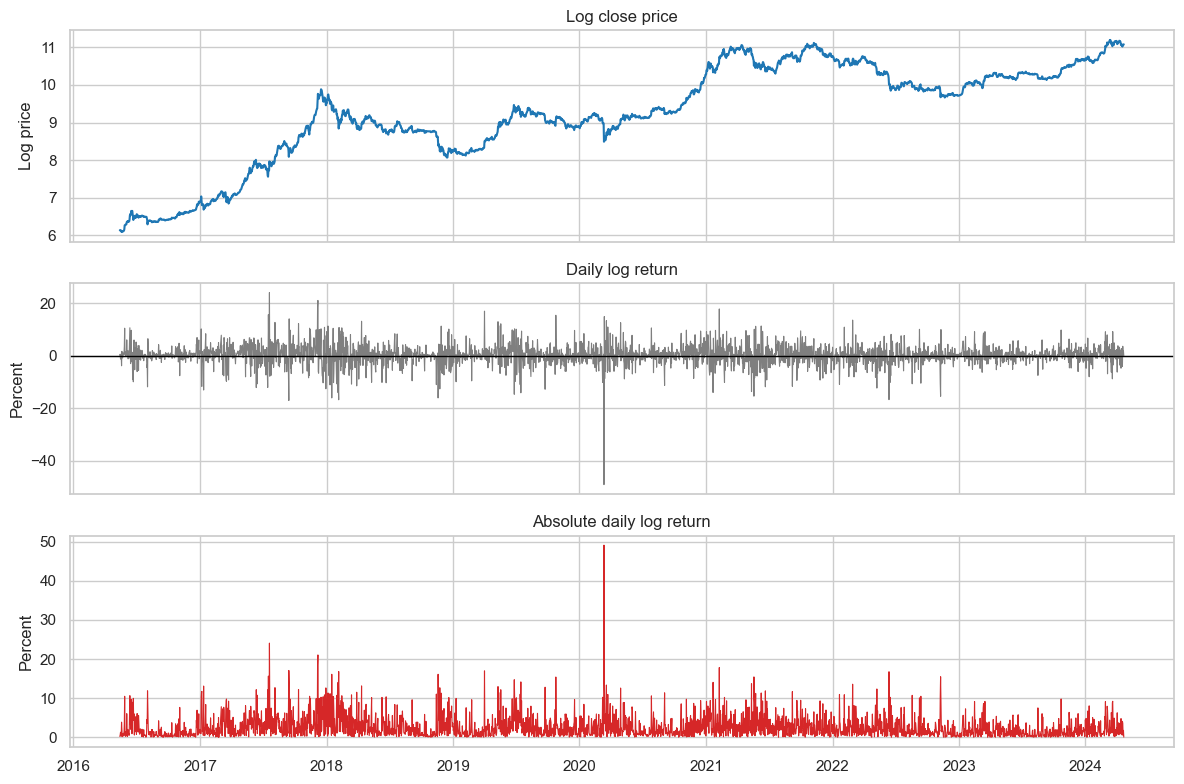

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(daily.index, daily["log_close"], color="tab:blue")
axes[0].set_title("Log close price")
axes[0].set_ylabel("Log price")

axes[1].plot(daily.index, daily["log_return_pct"], color="tab:gray", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Daily log return")
axes[1].set_ylabel("Percent")

axes[2].plot(daily.index, daily["abs_log_return_pct"], color="tab:red", linewidth=0.8)
axes[2].set_title("Absolute daily log return")
axes[2].set_ylabel("Percent")

plt.tight_layout()
plt.show()

### Autocorrelation Plots

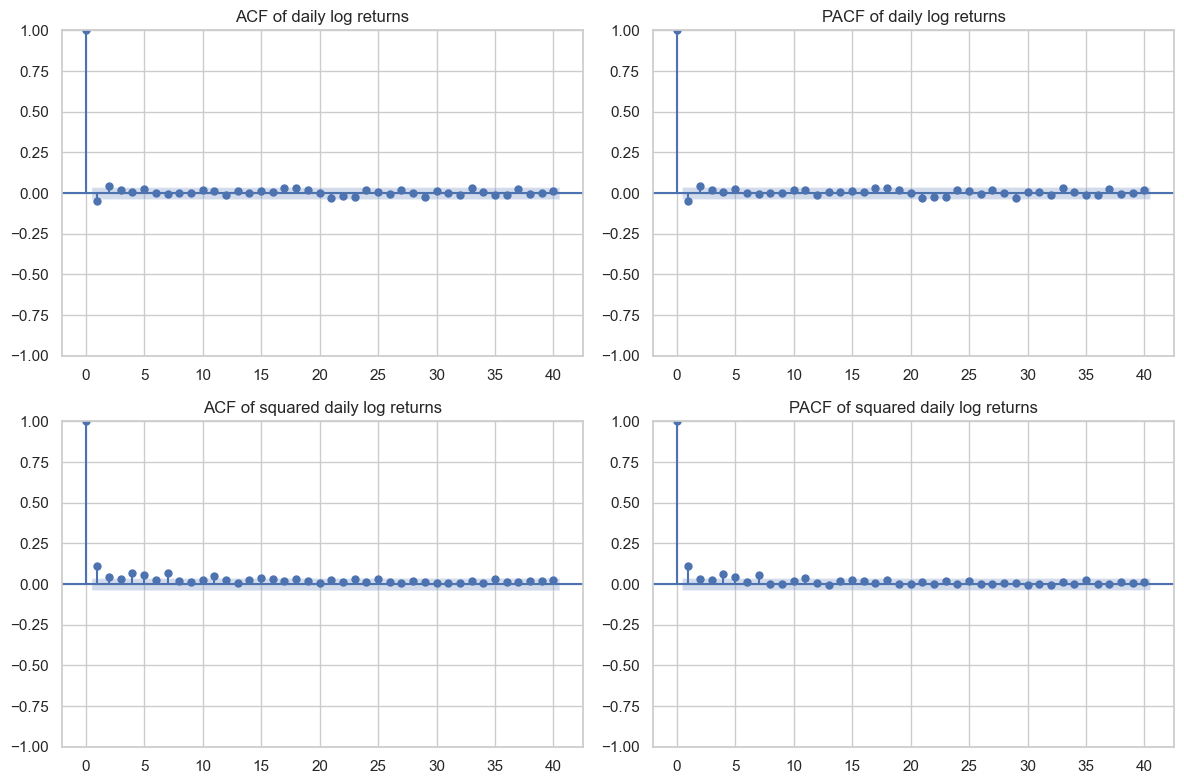

In [27]:
returns = daily["log_return"].dropna()
squared_returns = daily["squared_log_return"].dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_acf(returns, lags=40, ax=axes[0, 0])
plot_pacf(returns, lags=40, ax=axes[0, 1], method="ywm")
plot_acf(squared_returns, lags=40, ax=axes[1, 0])
plot_pacf(squared_returns, lags=40, ax=axes[1, 1], method="ywm")

axes[0, 0].set_title("ACF of daily log returns")
axes[0, 1].set_title("PACF of daily log returns")
axes[1, 0].set_title("ACF of squared daily log returns")
axes[1, 1].set_title("PACF of squared daily log returns")

plt.tight_layout()
plt.show()

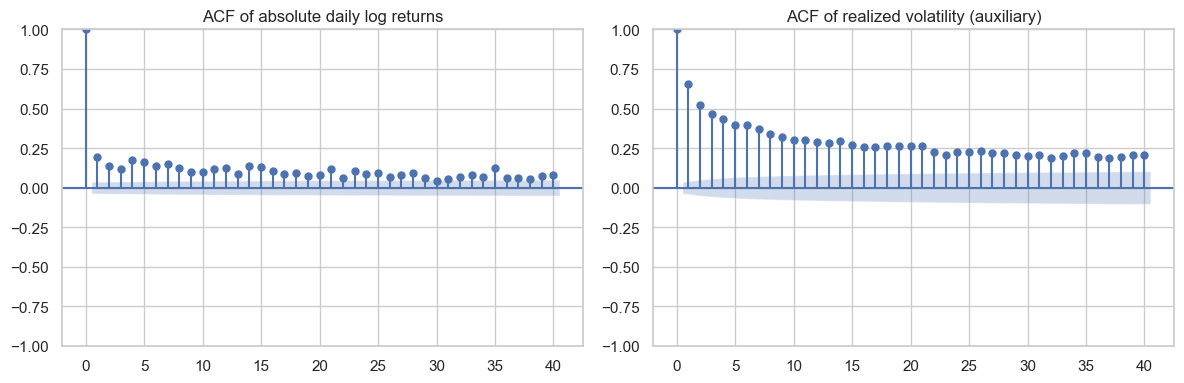

In [28]:
absolute_returns = daily["abs_log_return"].dropna()
realized_vol = daily["realized_volatility"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(absolute_returns, lags=40, ax=axes[0])
plot_acf(realized_vol, lags=40, ax=axes[1])
axes[0].set_title("ACF of absolute daily log returns")
axes[1].set_title("ACF of realized volatility (auxiliary)")
plt.tight_layout()
plt.show()

### Ljung-Box Tests

In [29]:
ljung_lags = [5, 10, 20]

ljung_inputs = {
    "daily log return": returns,
    "absolute daily log return": absolute_returns,
    "squared daily log return": squared_returns,
    "realized volatility, auxiliary": realized_vol,
}

ljung_rows = []
for series_name, series_values in ljung_inputs.items():
    result = acorr_ljungbox(series_values, lags=ljung_lags, return_df=True)
    result["series"] = series_name
    result.index.name = "lag"
    ljung_rows.append(result.reset_index())

ljung_box_summary = pd.concat(ljung_rows, ignore_index=True)[
    ["series", "lag", "lb_stat", "lb_pvalue"]
]

ljung_box_summary

,series,lag,lb_stat,lb_pvalue
0,daily log return,5,15.988085,0.006878
1,daily log return,10,16.953575,0.075398
2,daily log return,20,25.552091,0.181120
3,absolute daily log return,5,361.820531,0.000000
4,absolute daily log return,10,583.789979,0.000000
5,absolute daily log return,20,906.524503,0.000000
6,squared daily log return,5,66.920866,0.000000
7,squared daily log return,10,85.325117,0.000000
8,squared daily log return,20,107.169079,0.000000
9,"realized volatility, auxiliary",5,"3,653.257676",0.000000


In [30]:
ljung_box_summary.assign(significant=ljung_box_summary["lb_pvalue"] < 0.05)

,series,lag,lb_stat,lb_pvalue,significant
0,daily log return,5,15.988085,0.006878,True
1,daily log return,10,16.953575,0.075398,False
2,daily log return,20,25.552091,0.181120,False
3,absolute daily log return,5,361.820531,0.000000,True
4,absolute daily log return,10,583.789979,0.000000,True
5,absolute daily log return,20,906.524503,0.000000,True
6,squared daily log return,5,66.920866,0.000000,True
7,squared daily log return,10,85.325117,0.000000,True
8,squared daily log return,20,107.169079,0.000000,True
9,"realized volatility, auxiliary",5,"3,653.257676",0.000000,True


The Ljung-Box test separates two parts of the return process. Raw daily log returns have limited autocorrelation, which means the conditional mean is difficult to forecast from simple linear dependence alone.

Absolute and squared daily log returns show stronger dependence. This indicates volatility clustering: large market moves tend to be followed by periods of larger moves, and calm periods tend to persist.

Realized volatility, kept here as an auxiliary intraday-based measure, also shows persistence. This supports the hybrid project design: the LSTM targets the next daily log return, while the SGARCH component is motivated by persistent volatility in the residual or return magnitude process.